# 8. Experimento combinatorio de clasificación

## 8.1. Diseño

El experimento cruza cada modelo base con cada estrategia de balanceo y cada método de optimización. El resultado es un producto, no una suma:

| Etapa | Alternativas | Detalle |
|---|---|---|
| Modelos base | 7 | k-NN, Naive Bayes, regresión logística (L1/L2), árbol de decisión, Random Forest, XGBoost, SVM |
| Balanceo de clases | 4 | Sin balanceo, SMOTE, ADASYN, `class_weight="balanced"` |
| Optimización de hiperparámetros | 4 | Grid Search, Random Search, bayesiana (Optuna), genética |
| **Total** | **7 × 4 × 4 = 112** | Cada combinación se entrena, optimiza y evalúa de forma independiente |

Cada una de las 112 corridas atraviesa la validación anidada del capítulo 6: cinco folds externos para estimar desempeño, tres internos para seleccionar hiperparámetros, y agrupamiento por paciente en ambos niveles. Las métricas que se reportan provienen siempre del bucle externo.

### 8.1.1. Equivalentes de `class_weight`

Dos de los siete modelos no implementan el parámetro `class_weight`, y la guía exige registrar explícitamente lo que ocurre con esas combinaciones en lugar de omitirlas en silencio:

| Modelo | Tratamiento | Justificación |
|---|---|---|
| Naive Bayes | `priors=[0.5, 0.5]` | Fijar probabilidades a priori uniformes elimina la ventaja estructural de la clase mayoritaria en el producto posterior. Es el equivalente exacto del reponderado |
| XGBoost | `scale_pos_weight` | El parámetro multiplica el gradiente de la clase positiva; se fija en la razón entre clases del conjunto de entrenamiento |
| k-NN | **No aplicable** | Su predicción es un voto entre vecinos, sin término de pérdida que ponderar. No existe equivalente sin alterar el algoritmo, así que las cuatro combinaciones con `class_weight` se registran como no aplicables |

Eso deja 108 corridas ejecutables y 4 celdas documentadas como imposibles, distinción que el capítulo 11 necesita para aplicar la prueba de Friedman sobre un diseño completo.

In [1]:
from config import *

import experimento as ex

# 4 procesos, el número de núcleos físicos del equipo (sección 7.2).
ex.N_JOBS = 4

train = leer_tabla("diabetes_train")
roles = roles_variables()

OBJETIVO = roles["objetivo"]
IDENTIFICADOR = roles["identificador"]
PREDICTORES = (roles["numericas"] + roles["ordinales"]
               + roles["binarias"] + roles["categoricas"])

X = train[PREDICTORES]
y = train[OBJETIVO]
grupos = train[IDENTIFICADOR]

# Razón entre clases, necesaria para el scale_pos_weight de XGBoost.
RAZON_DESBALANCE = float((1 - y.mean()) / y.mean())

print(f"Entrenamiento    : {len(X):,} encuentros de {grupos.nunique():,} pacientes")
print(f"Clase positiva   : {y.mean():.2%}")
print(f"Razón desbalance : {RAZON_DESBALANCE:.2f} a 1")
print(f"Modelos          : {ex.MODELOS}")
print(f"Balanceos        : {ex.BALANCEOS}")
print(f"Optimizadores    : {ex.OPTIMIZADORES}")
print(f"Procesos         : {ex.N_JOBS}")

Entrenamiento    : 79,473 encuentros de 56,036 pacientes
Clase positiva   : 11.39%
Razón desbalance : 7.78 a 1
Modelos          : ['knn', 'bayes', 'logistica', 'arbol', 'random_forest', 'xgboost', 'svm']
Balanceos        : ['ninguno', 'smote', 'adasyn', 'class_weight']
Optimizadores    : ['grid', 'random', 'optuna', 'deap']
Procesos         : 4


## 8.2. Presupuesto y multi-fidelidad

El capítulo 6 midió el costo por ajuste de cada familia y proyectó el experimento completo en unas 24 horas de cómputo. La ejecución real totalizó 22.9 horas, de modo que la proyección quedó algo por encima del costo efectivo. Se aplican tres medidas, todas declaradas antes de ejecutar y registradas en la tabla maestra.

**Presupuesto por modelo.** Cada modelo evalúa tantas configuraciones como tiene su rejilla: 12 en los económicos y 8 en los costosos (k-NN, Random Forest y XGBoost), cuyo costo por evaluación, medido en el capítulo 6, duplica al de los modelos lineales y en Random Forest lo sextuplica. El presupuesto es **idéntico para los cuatro optimizadores de un mismo modelo**, de modo que la comparación entre optimizadores del capítulo 9 sea a igualdad de evaluaciones. Entre modelos, en cambio, introduce una asimetría: un modelo con 8 configuraciones explora menos su espacio que uno con 12, y eso lo penaliza. La columna `presupuesto` de la tabla maestra permite tenerlo en cuenta al comparar.

**Multi-fidelidad, primer mecanismo: Successive Halving.** Viene del motor y solo afecta a Optuna. La fidelidad es el número de folds internos evaluados: una configuración que tras el primer fold no está en el tercio superior se descarta sin evaluar los dos restantes (factor de reducción η = 3). La columna `n_ajustes` registra cuántos ajustes consumió realmente cada corrida, lo que permite medir el ahorro en el capítulo 9.

**Multi-fidelidad, segundo mecanismo: submuestreo de pacientes.** La búsqueda interna de los modelos costosos se ejecuta sobre el **25 % de los pacientes** del fold externo de entrenamiento (factor de reducción 4); el ajuste final de cada fold externo usa siempre todos sus datos, de modo que las métricas reportadas no pierden precisión. La submuestra se toma por paciente y no por fila, así que la integridad de los grupos se mantiene también en la búsqueda. Se aplica igual a los cuatro optimizadores del mismo modelo, por la misma razón que el presupuesto.

El factor 4 se elige para dejar unos 10,000 pacientes en la búsqueda, suficientes para estimar el AUC-PR con una precisión del orden de 0.01, que es la escala de las diferencias entre configuraciones. La fracción queda registrada en la columna `fraccion_busqueda`.

El supuesto que introduce el submuestreo es que el orden relativo entre configuraciones se conserva al reducir la muestra. No se da por bueno: el capítulo 9 lo verifica de forma directa, repitiendo la búsqueda de los modelos económicos con el 25 % y comparando la configuración elegida con la que sale del fold completo.

**Condiciones de ejecución.** Todas las corridas se ejecutan con 4 procesos en paralelo (`N_JOBS = 4`), el número de núcleos físicos del equipo: duplicarlo a 8 aprovechando el hyperthreading acorta la búsqueda apenas un 9 % y duplica la memoria, lo que en ejecuciones de varias horas llegó a agotar los recursos del sistema. En las corridas de Optuna con modelos secuenciales, que no pueden repartir sus configuraciones entre núcleos, los cinco folds externos se ejecutan a la vez; las métricas son idénticas a las de la ejecución en serie, porque los folds son independientes entre sí. La tabla maestra registra ambas condiciones (`n_jobs` y `folds_en_paralelo`) y dos medidas de costo: `tiempo_real_s`, el tiempo de reloj de la corrida, y `tiempo_trabajo_s`, la suma del cómputo de sus folds. Con los folds en serie coinciden; con los folds en paralelo, la segunda supera a la primera. El capítulo 9 declara cuál de las dos usa en cada comparación.

In [2]:
# Modelos cuyo costo por evaluación justifica reducir presupuesto y fidelidad
# (medición en el capítulo 6, sección 6.9): Random Forest por el ajuste, k-NN
# por la inferencia y XGBoost por no aprovechar el paralelismo entre
# configuraciones. Son también los tres que paralelizan internamente.
COSTOSOS = {"random_forest", "xgboost", "knn"}

FIDELIDAD_ECONOMICA, FIDELIDAD_COSTOSA = 1.0, 0.25


def construir_corridas(modelos=None, balanceos=None, optimizadores=None):
    """Genera las combinaciones del diseño con su fidelidad de búsqueda.

    El presupuesto no se fija aquí: lo deriva el motor del tamaño de la
    rejilla de cada modelo (`ex.presupuesto_modelo`), de modo que rejilla y
    presupuesto no puedan desincronizarse.

    Parameters
    ----------
    modelos, balanceos, optimizadores : list of str, optional
        Subconjuntos a generar. Por omisión, el diseño completo.

    Returns
    -------
    list of tuple
        Pares (Corrida, fracción de búsqueda).
    """
    modelos = modelos or ex.MODELOS
    balanceos = balanceos or ex.BALANCEOS
    optimizadores = optimizadores or ex.OPTIMIZADORES

    corridas = []
    for modelo in modelos:
        costoso = modelo in COSTOSOS
        for balanceo in balanceos:
            for optimizador in optimizadores:
                corridas.append((
                    ex.Corrida(
                        modelo=modelo, balanceo=balanceo,
                        optimizador=optimizador,
                        razon_desbalance=RAZON_DESBALANCE,
                    ),
                    FIDELIDAD_COSTOSA if costoso else FIDELIDAD_ECONOMICA,
                ))
    return corridas


diseno = construir_corridas()
resumen_diseno = pd.DataFrame([
    {"modelo": c.modelo, "balanceo": c.balanceo,
     "optimizador": c.optimizador,
     "presupuesto": ex.presupuesto_modelo(c.modelo),
     "fidelidad": f}
    for c, f in diseno
])
print(f"Corridas del diseño: {len(resumen_diseno)}")
resumen_diseno.groupby("modelo").agg(
    corridas=("modelo", "size"),
    presupuesto=("presupuesto", "first"),
    fidelidad=("fidelidad", "first"),
)

Corridas del diseño: 112


,corridas,presupuesto,fidelidad
modelo,,,
arbol,16,12,1.00
bayes,16,12,1.00
knn,16,8,0.25
logistica,16,12,1.00
random_forest,16,8,0.25
svm,16,12,1.00
xgboost,16,8,0.25


## 8.3. Ejecución

El ejecutor escribe cada corrida en la tabla maestra en cuanto termina y omite las ya presentes al reanudar, de modo que el experimento pueda repartirse en varias sesiones sin perder trabajo. La celda siguiente se puede interrumpir y volver a lanzar sin consecuencias.

Se ejecuta por bloques, de los modelos económicos a los costosos, para tener resultados parciales interpretables desde el principio. Cambia `BLOQUES_A_EJECUTAR` para lanzar solo una parte.

In [3]:
RUTA_TABLA = RESULTADOS / "tabla_maestra_clasificacion.csv"

BLOQUES = {
    "economicos": ["bayes", "logistica", "arbol", "svm"],
    "costosos": ["knn", "random_forest", "xgboost"],
}

# Ajusta esta lista para ejecutar por partes. Con [] no se ejecuta nada y solo
# se analiza lo que ya esté en la tabla maestra.
BLOQUES_A_EJECUTAR = ["costosos"]

In [4]:
import time

for nombre_bloque in BLOQUES_A_EJECUTAR:
    modelos = BLOQUES[nombre_bloque]
    print(f"\n{'=' * 70}\nBloque: {nombre_bloque} ({', '.join(modelos)})\n"
          f"{'=' * 70}")
    inicio = time.perf_counter()

    for corrida, fidelidad in construir_corridas(modelos=modelos):
        ex.ejecutar_experimento(
            [corrida], X, y, grupos, roles,
            ruta_tabla=RUTA_TABLA,
            folds_externos=5, folds_internos=3,
            metrica="average_precision",
            fraccion_busqueda=fidelidad,
        )

    print(f"\nBloque {nombre_bloque} terminado en "
          f"{(time.perf_counter() - inicio) / 60:.1f} min")


Bloque: costosos (knn, random_forest, xgboost)
[omitida] knn|ninguno|grid
[omitida] knn|ninguno|random
[omitida] knn|ninguno|optuna
[omitida] knn|ninguno|deap
[omitida] knn|smote|grid
[omitida] knn|smote|random


[omitida] knn|smote|optuna
[omitida] knn|smote|deap
[omitida] knn|adasyn|grid


[omitida] knn|adasyn|random
[omitida] knn|adasyn|optuna
[omitida] knn|adasyn|deap
[omitida] knn|class_weight|grid
[omitida] knn|class_weight|random
[omitida] knn|class_weight|optuna
[omitida] knn|class_weight|deap
[omitida] random_forest|ninguno|grid
[omitida] random_forest|ninguno|random


[omitida] random_forest|ninguno|optuna


[omitida] random_forest|ninguno|deap
[omitida] random_forest|smote|grid
[omitida] random_forest|smote|random
[omitida] random_forest|smote|optuna
[omitida] random_forest|smote|deap
[omitida] random_forest|adasyn|grid
[omitida] random_forest|adasyn|random
[omitida] random_forest|adasyn|optuna
[omitida] random_forest|adasyn|deap
[omitida] random_forest|class_weight|grid


[omitida] random_forest|class_weight|random
[omitida] random_forest|class_weight|optuna
[omitida] random_forest|class_weight|deap
[omitida] xgboost|ninguno|grid
[omitida] xgboost|ninguno|random
[omitida] xgboost|ninguno|optuna
[omitida] xgboost|ninguno|deap
[omitida] xgboost|smote|grid
[omitida] xgboost|smote|random
[omitida] xgboost|smote|optuna
[omitida] xgboost|smote|deap


[omitida] xgboost|adasyn|grid
[omitida] xgboost|adasyn|random
[omitida] xgboost|adasyn|optuna
[omitida] xgboost|adasyn|deap
[omitida] xgboost|class_weight|grid
[omitida] xgboost|class_weight|random
[omitida] xgboost|class_weight|optuna
[omitida] xgboost|class_weight|deap

Bloque costosos terminado en 0.0 min


La métrica que guía la búsqueda interna es la **precisión media** (AUC-PR). La razón es el desbalance: con un 11.4 % de clase positiva, el AUC-ROC se calcula sobre un eje de falsos positivos normalizado por una clase mayoritaria muy grande, lo que lo hace poco sensible a mejoras en la clase de interés. El AUC-PR, en cambio, responde directamente a la capacidad de identificar readmisiones sin inundar de falsos positivos la lista de seguimiento.

## 8.4. Resultados

In [5]:
maestra = pd.read_csv(RUTA_TABLA)
completadas = maestra.query("estado == 'completada'").copy()

print(f"Corridas registradas : {len(maestra)}")
print(f"  completadas        : {len(completadas)}")
print(f"  no aplicables      : {(maestra['estado'] == 'no aplicable').sum()}")
print(f"Tiempo total acumulado: "
      f"{maestra['tiempo_total_s'].sum() / 3600:.2f} h")

# reindex, no indexación directa: mientras no haya ninguna fila no aplicable
# la columna "detalle" todavía no existe en la tabla maestra.
maestra.query("estado == 'no aplicable'").reindex(
    columns=["modelo", "balanceo", "optimizador", "detalle"])

Corridas registradas : 112
  completadas        : 108
  no aplicables      : 4
Tiempo total acumulado: 22.91 h


,modelo,balanceo,optimizador,detalle
76,knn,class_weight,grid,'knn' no tiene equivalente de class_weight: su...
77,knn,class_weight,random,'knn' no tiene equivalente de class_weight: su...
78,knn,class_weight,optuna,'knn' no tiene equivalente de class_weight: su...
79,knn,class_weight,deap,'knn' no tiene equivalente de class_weight: su...


In [6]:
# Tiempo de cómputo por bloque, reconstruido desde la tabla maestra: suma el
# tiempo de cada corrida completada, así que es correcto aunque el bloque se
# haya ejecutado en varias sesiones. tiempo_total_s es el tiempo de reloj de
# cada corrida y existe en todas las filas.
bloque_de = {m: b for b, modelos in BLOQUES.items() for m in modelos}

tiempos_bloque = (
    completadas.assign(bloque=completadas["modelo"].map(bloque_de))
    .groupby("bloque")
    .agg(corridas=("modelo", "size"),
         horas=("tiempo_total_s", lambda s: s.sum() / 3600),
         minutos_por_corrida=("tiempo_total_s", lambda s: s.mean() / 60))
    .round(2)
)

tiempos_modelo = (
    completadas.assign(bloque=completadas["modelo"].map(bloque_de))
    .groupby("modelo")
    .agg(bloque=("bloque", "first"),
         corridas=("modelo", "size"),
         horas=("tiempo_total_s", lambda s: s.sum() / 3600))
    .sort_values("horas", ascending=False)
    .round(2)
)

print(f"Tiempo total del experimento: {tiempos_bloque['horas'].sum():.2f} h")
display(tiempos_bloque)
tiempos_modelo

Tiempo total del experimento: 22.91 h


,corridas,horas,minutos_por_corrida
bloque,,,
costosos,44,9.64,13.15
economicos,64,13.27,12.44


,bloque,corridas,horas
modelo,,,
logistica,economicos,16,5.72
random_forest,costosos,16,5.41
svm,economicos,16,3.49
knn,costosos,12,2.35
bayes,economicos,16,2.05
arbol,economicos,16,2.00
xgboost,costosos,16,1.89


In [7]:
COLUMNAS_RESUMEN = [
    "modelo", "balanceo", "optimizador", "presupuesto", "fraccion_busqueda",
    "auc_pr_media", "auc_pr_sd", "auc_roc_media", "auc_roc_sd",
    "recall_media", "precision_media", "f1_media",
    "exactitud_balanceada_media", "brier_media",
    "n_evaluaciones", "n_ajustes", "tiempo_por_evaluacion_s",
    "tiempo_busqueda_s", "tiempo_ajuste_s", "tiempo_inferencia_s",
    "tiempo_real_s", "tiempo_trabajo_s", "n_jobs", "folds_en_paralelo",
    "semilla",
]

ranking = completadas.sort_values("auc_pr_media", ascending=False)
# reindex: las corridas anteriores a las columnas de condiciones de
# ejecución no las tienen, y quedan vacías en lugar de producir un error.
tabla(ranking.reindex(columns=COLUMNAS_RESUMEN).round(4), filas=25)

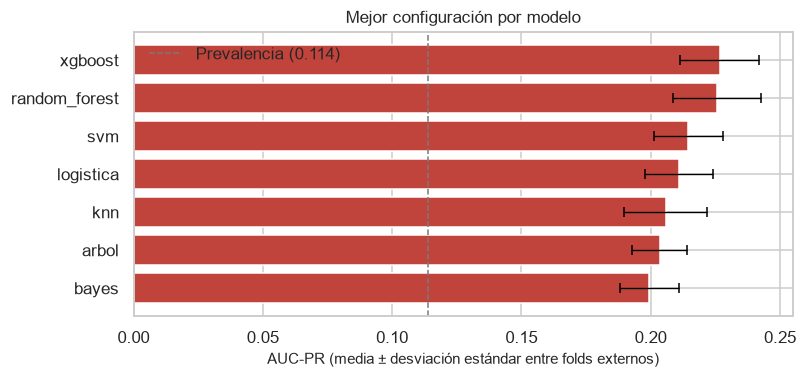

,modelo,balanceo,optimizador,auc_pr_media,auc_pr_sd,auc_roc_media,tiempo_ajuste_s
105,xgboost,adasyn,random,0.2267,0.0153,0.6689,241.9583
83,random_forest,ninguno,deap,0.2258,0.0170,0.6703,240.8178
48,svm,ninguno,grid,0.2145,0.0133,0.6626,27.9781
18,logistica,ninguno,optuna,0.2110,0.0131,0.6619,68.0067
64,knn,ninguno,grid,0.2058,0.0160,0.6504,26.4822
32,arbol,ninguno,grid,0.2034,0.0106,0.6522,28.1186
1,bayes,ninguno,random,0.1995,0.0115,0.6479,25.4877


In [8]:
# Mejor configuración de cada modelo, con su desviación estándar entre folds.
mejores = (completadas.loc[completadas.groupby("modelo")["auc_pr_media"]
                                     .idxmax()]
                      .sort_values("auc_pr_media", ascending=False))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
posiciones = np.arange(len(mejores))
ax.barh(posiciones, mejores["auc_pr_media"], xerr=mejores["auc_pr_sd"],
        color=PALETA[1], error_kw={"ecolor": "black", "capsize": 3,
                                   "elinewidth": 0.9})
ax.set_yticks(posiciones)
ax.set_yticklabels(mejores["modelo"])
ax.invert_yaxis()
ax.axvline(y.mean(), ls="--", color=GRIS, lw=1,
           label=f"Prevalencia ({y.mean():.3f})")
ax.set_xlabel("AUC-PR (media ± desviación estándar entre folds externos)")
ax.set_title("Mejor configuración por modelo")
ax.legend()
plt.tight_layout()
plt.show()

guardar_resultado(mejores.set_index("modelo").reindex(columns=COLUMNAS_RESUMEN[1:]),
                  "mejores_por_modelo")
mejores[["modelo", "balanceo", "optimizador", "auc_pr_media", "auc_pr_sd",
         "auc_roc_media", "tiempo_ajuste_s"]].round(4)

La línea discontinua marca la prevalencia de la clase positiva, que es el AUC-PR que obtendría un clasificador aleatorio. La distancia de cada barra a esa línea es la señal real que captura el modelo.

Al leer esta figura conviene comparar las diferencias entre modelos con las barras de error. Si los intervalos se solapan ampliamente, la diferencia observada puede ser ruido de partición y no una ventaja real: es precisamente la pregunta que el capítulo 11 responde con pruebas formales en lugar de con inspección visual.

Las columnas de costo (`n_evaluaciones`, `n_ajustes` y `tiempo_por_evaluacion_s`) se incluyen en el ranking porque son las que permiten leer cada resultado junto a lo que costó obtenerlo. Su comparación sistemática entre optimizadores corresponde al capítulo 9.

### 8.4.1. Efecto de las estrategias de balanceo

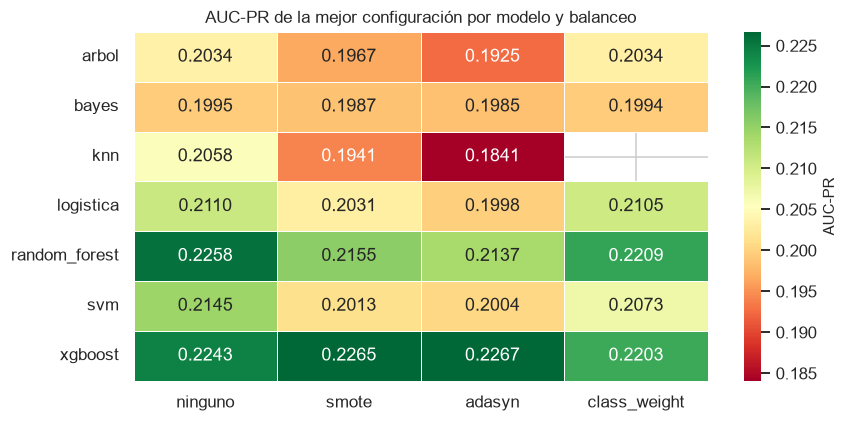

balanceo,ninguno,smote,adasyn,class_weight
modelo,,,,
arbol,0.2034,0.1967,0.1925,0.2034
bayes,0.1995,0.1987,0.1985,0.1994
knn,0.2058,0.1941,0.1841,NaN
logistica,0.2110,0.2031,0.1998,0.2105
random_forest,0.2258,0.2155,0.2137,0.2209
svm,0.2145,0.2013,0.2004,0.2073
xgboost,0.2243,0.2265,0.2267,0.2203


In [9]:
comparacion_balanceo = (completadas.pivot_table(
    index="modelo", columns="balanceo", values="auc_pr_media",
    aggfunc="max"))
orden_balanceo = [b for b in ex.BALANCEOS if b in comparacion_balanceo.columns]
comparacion_balanceo = comparacion_balanceo[orden_balanceo]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(comparacion_balanceo, annot=True, fmt=".4f", cmap="RdYlGn",
            linewidths=0.5, cbar_kws={"label": "AUC-PR"}, ax=ax)
ax.set_title("AUC-PR de la mejor configuración por modelo y balanceo")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

comparacion_balanceo.round(4)

In [10]:
# Ganancia de cada estrategia frente a la ausencia de balanceo, por modelo.
if "ninguno" in comparacion_balanceo.columns:
    ganancia = comparacion_balanceo.sub(comparacion_balanceo["ninguno"],
                                        axis=0).drop(columns="ninguno")
    resumen_ganancia = pd.DataFrame({
        "ganancia media en AUC-PR": ganancia.mean(),
        "ganancia mínima": ganancia.min(),
        "ganancia máxima": ganancia.max(),
        "modelos donde mejora": (ganancia > 0).sum(),
    }).round(4)
    display(resumen_ganancia)
    display(ganancia.round(4))

,ganancia media en AUC-PR,ganancia mínima,ganancia máxima,modelos donde mejora
balanceo,,,,
smote,-0.0069,-0.0132,0.0023,1
adasyn,-0.0098,-0.0218,0.0024,1
class_weight,-0.0028,-0.0072,-0.0001,0


balanceo,smote,adasyn,class_weight
modelo,,,
arbol,-0.0067,-0.0109,-0.0001
bayes,-0.0008,-0.0010,-0.0001
knn,-0.0118,-0.0218,NaN
logistica,-0.0079,-0.0112,-0.0005
random_forest,-0.0102,-0.0121,-0.0049
svm,-0.0132,-0.0141,-0.0072
xgboost,0.0023,0.0024,-0.0039


In [11]:
# El balanceo actúa sobre el umbral implícito, así que su efecto es mucho
# mayor en métricas dependientes del umbral que en las de ordenamiento.
efecto_umbral = completadas.pivot_table(
    index="balanceo", values=["auc_pr_media", "auc_roc_media", "recall_media",
                              "precision_media", "f1_media"],
    aggfunc="mean").reindex(orden_balanceo).round(4)
efecto_umbral

,auc_pr_media,auc_roc_media,f1_media,precision_media,recall_media
balanceo,,,,,
ninguno,0.2102,0.6575,0.0431,0.3990,0.0375
smote,0.2027,0.6476,0.1913,0.2685,0.3929
adasyn,0.1999,0.6452,0.1814,0.2561,0.4072
class_weight,0.2088,0.6589,0.2251,0.2381,0.4504


Esta última tabla es clave para interpretar el papel del balanceo y conviene discutirla con cuidado en el informe.

Las métricas de ordenamiento (AUC-PR y AUC-ROC) miden si el modelo asigna mayor riesgo a los pacientes que efectivamente reingresan, con independencia de dónde se ponga el umbral de decisión. Las métricas de clasificación (recall, precisión, F1) se calculan con umbral 0.5 y por tanto dependen de cómo el modelo distribuya sus probabilidades.

El balanceo desplaza esa distribución: sube las probabilidades predichas de la clase minoritaria y, con umbral fijo, aumenta el recall a costa de la precisión. Eso puede parecer una mejora si solo se mira el recall, pero en las métricas de ordenamiento el efecto suele ser mucho menor. La conclusión metodológica es que **el balanceo y la elección del umbral resuelven el mismo problema por vías distintas**, y que comparar modelos por recall con umbral 0.5 confunde ambos efectos. El capítulo 10 separa las dos decisiones eligiendo el umbral de forma explícita.

Un caso extremo que aparece en los resultados: sin balanceo y con umbral 0.5, varios modelos tienen recall cercano a cero, porque prácticamente ninguna probabilidad predicha supera 0.5 cuando la prevalencia es del 11 %. Su AUC-PR, en cambio, es competitivo. Eso demuestra que el umbral por defecto es inadecuado en este problema, no que los modelos sin balanceo sean malos.

### 8.4.2. Desempeño frente a costo

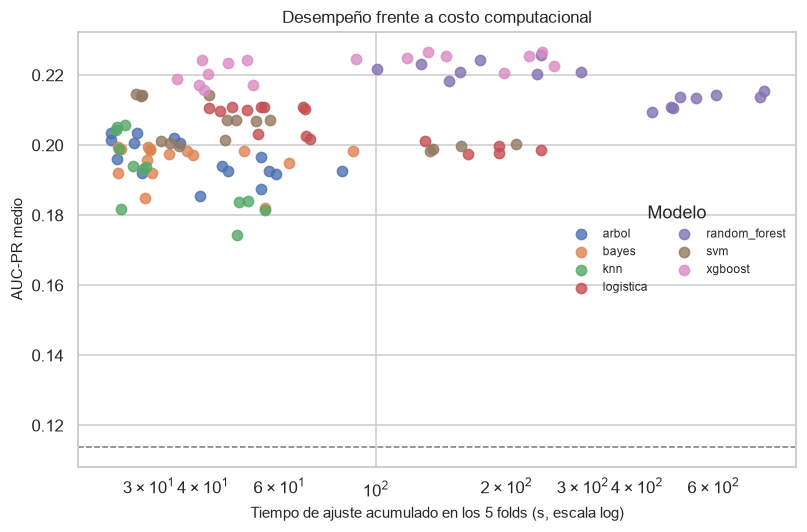

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for modelo, grupo in completadas.groupby("modelo"):
    ax.scatter(grupo["tiempo_ajuste_s"], grupo["auc_pr_media"],
               label=modelo, s=45, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel("Tiempo de ajuste acumulado en los 5 folds (s, escala log)")
ax.set_ylabel("AUC-PR medio")
ax.set_title("Desempeño frente a costo computacional")
ax.axhline(y.mean(), ls="--", color=GRIS, lw=1)
ax.legend(title="Modelo", fontsize=8, ncols=2)
plt.tight_layout()
plt.show()

Este gráfico responde a una pregunta que la guía plantea de forma explícita: si la complejidad añadida se traduce en mejora. Un modelo situado arriba y a la izquierda domina, porque logra más desempeño con menos cómputo. Si los ensambles aparecen a la derecha sin estar claramente más arriba que los modelos lineales, el coste no está justificado para este problema.

### 8.4.3. Estabilidad frente a la semilla

La media y la desviación estándar entre folds capturan la variabilidad de una partición concreta. Repetir la mejor configuración con otras semillas mide algo más amplio: la semilla gobierna a la vez el reparto en folds, la submuestra de la búsqueda y la aleatoriedad interna de los algoritmos (arranque de Optuna, población inicial del genético, remuestreo de SMOTE, árboles de Random Forest). El rango entre semillas es, por tanto, la variabilidad total del procedimiento de principio a fin, no solo la del algoritmo.

Esa es justamente la cifra que hace falta para interpretar el ranking: si dos combinaciones difieren menos de lo que varía una sola combinación al cambiar de semilla, la diferencia no es atribuible al método.

In [13]:
SEMILLAS = [42, 7, 2026]
mejor_global = ranking.iloc[0]

filas = []
for semilla in SEMILLAS:
    corrida = ex.Corrida(
        modelo=mejor_global["modelo"], balanceo=mejor_global["balanceo"],
        optimizador=mejor_global["optimizador"],
        razon_desbalance=RAZON_DESBALANCE,
    )
    resultado = ex.ejecutar_corrida(
        corrida, X, y, grupos, roles, folds_externos=5, folds_internos=3,
        fraccion_busqueda=(FIDELIDAD_COSTOSA
                           if mejor_global["modelo"] in COSTOSOS
                           else FIDELIDAD_ECONOMICA),
        semilla=semilla,
    )
    filas.append({"semilla": semilla,
                  "auc_pr_media": resultado["auc_pr_media"],
                  "auc_pr_sd": resultado["auc_pr_sd"],
                  "auc_roc_media": resultado["auc_roc_media"]})

sensibilidad = pd.DataFrame(filas).set_index("semilla").round(4)
sensibilidad.loc["rango"] = (sensibilidad.max() - sensibilidad.min())
guardar_resultado(sensibilidad, "sensibilidad_semillas")
sensibilidad

,auc_pr_media,auc_pr_sd,auc_roc_media
semilla,,,
42,0.2267,0.0153,0.6689
7,0.2259,0.0063,0.6697
2026,0.2226,0.0122,0.6673
rango,0.0041,0.0090,0.0024


La fila `rango` es la que importa: si la variación entre semillas es del mismo orden que las diferencias entre combinaciones del ranking, esas diferencias no son interpretables sin pruebas estadísticas. Es el argumento que motiva el capítulo 11.

### 8.4.4. Validación del submuestreo de búsqueda

La sección 8.2 introdujo la multi-fidelidad con un supuesto explícito: que el orden
relativo entre configuraciones se conserva al reducir la muestra de búsqueda. Mientras
no se verifique, queda abierta una objeción de fondo a la comparación entre modelos,
porque los tres modelos costosos buscaron con el 25 % de los pacientes y los cuatro
económicos con todos. Una ventaja de los costosos sería conservadora bajo ese sesgo,
pero una desventaja no sería interpretable.

El supuesto se contrasta en las dos direcciones, sobre el balanceo `ninguno` para
aislar el efecto del submuestreo del que introduce el remuestreo:

1. **Económicos a fidelidad reducida.** Se repiten con el 25 % de los pacientes. Si la
   búsqueda elige la misma configuración y el desempeño no se mueve, el submuestreo es
   inocuo donde puede medirse contra su propio término de comparación.
2. **Costosos a fidelidad completa.** Se repiten con todos los pacientes. Es la prueba
   directa sobre los modelos que llevan el handicap, sin extrapolar desde los otros.

Ambas conservan presupuesto, semilla y particiones; la única variable que cambia es
`fraccion_busqueda`. Las corridas se escriben en tablas aparte, porque el ejecutor
omite las combinaciones ya presentes en el archivo que recibe y estas comparten
identificador con las de la tabla maestra.

In [14]:
RUTA_FIDELIDAD = RESULTADOS / "tabla_maestra_fidelidad.csv"
MODELOS_ECONOMICOS = ["bayes", "logistica", "arbol", "svm"]

for corrida, _ in construir_corridas(modelos=MODELOS_ECONOMICOS,
                                     balanceos=["ninguno"]):
    ex.ejecutar_experimento(
        [corrida], X, y, grupos, roles,
        ruta_tabla=RUTA_FIDELIDAD,
        folds_externos=5, folds_internos=3,
        metrica="average_precision",
        fraccion_busqueda=0.25,
    )

[omitida] bayes|ninguno|grid
[omitida] bayes|ninguno|random
[omitida] bayes|ninguno|optuna
[omitida] bayes|ninguno|deap
[omitida] logistica|ninguno|grid
[omitida] logistica|ninguno|random
[omitida] logistica|ninguno|optuna
[omitida] logistica|ninguno|deap
[omitida] arbol|ninguno|grid
[omitida] arbol|ninguno|random
[omitida] arbol|ninguno|optuna
[omitida] arbol|ninguno|deap
[omitida] svm|ninguno|grid
[omitida] svm|ninguno|random
[omitida] svm|ninguno|optuna
[omitida] svm|ninguno|deap


In [15]:
RUTA_COSTOSOS_FID1 = RESULTADOS / "tabla_maestra_costosos_fid1.csv"
MODELOS_COSTOSOS = ["xgboost", "knn", "random_forest"]

for corrida, _ in construir_corridas(modelos=MODELOS_COSTOSOS):
    ex.ejecutar_experimento(
        [corrida], X, y, grupos, roles,
        ruta_tabla=RUTA_COSTOSOS_FID1,
        folds_externos=5, folds_internos=3,
        metrica="average_precision",
        fraccion_busqueda=1.0,
    )

[omitida] xgboost|ninguno|grid
[omitida] xgboost|ninguno|random
[omitida] xgboost|ninguno|optuna
[omitida] xgboost|ninguno|deap
[omitida] xgboost|smote|grid
[omitida] xgboost|smote|random
[omitida] xgboost|smote|optuna


[omitida] xgboost|smote|deap
[omitida] xgboost|adasyn|grid
[omitida] xgboost|adasyn|random
[omitida] xgboost|adasyn|optuna
[omitida] xgboost|adasyn|deap
[omitida] xgboost|class_weight|grid
[omitida] xgboost|class_weight|random
[omitida] xgboost|class_weight|optuna
[omitida] xgboost|class_weight|deap
[omitida] knn|ninguno|grid
[omitida] knn|ninguno|random
[omitida] knn|ninguno|optuna
[omitida] knn|ninguno|deap
[omitida] knn|smote|grid


[omitida] knn|smote|random
[omitida] knn|smote|optuna
[omitida] knn|smote|deap
[omitida] knn|adasyn|grid
[omitida] knn|adasyn|random
[omitida] knn|adasyn|optuna
[omitida] knn|adasyn|deap


[omitida] knn|class_weight|grid
[omitida] knn|class_weight|random
[omitida] knn|class_weight|optuna
[omitida] knn|class_weight|deap
[omitida] random_forest|ninguno|grid
[omitida] random_forest|ninguno|random
[omitida] random_forest|ninguno|optuna
[omitida] random_forest|ninguno|deap
[omitida] random_forest|smote|grid
[omitida] random_forest|smote|random
[omitida] random_forest|smote|optuna
[omitida] random_forest|smote|deap
[omitida] random_forest|adasyn|grid


[omitida] random_forest|adasyn|random
[omitida] random_forest|adasyn|optuna


...

listo en 637.7 s (auc_pr 0.2152)


  fold externo 5/5... 

\

[... este mismo aviso se repitio 175,940 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

s

[... este mismo aviso se repitio 140,752 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

e

[... este mismo aviso se repitio 123,158 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

a

[... este mismo aviso se repitio 105,564 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

l

[... este mismo aviso se repitio 105,564 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

i

[... este mismo aviso se repitio 87,970 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

r

[... este mismo aviso se repitio 70,376 veces durante la corrida; se conserva una sola copia para no inflar el notebook ...]

o

[... este mismo aviso se repitio 70,376 veces durante la corrida; se conserva una sola co

listo en 938.7 s (auc_pr 0.2237)


[completada] random_forest|class_weight|deap: auc_pr 0.2207 ± 0.0138 en 3641.3 s


La lectura de la tabla siguiente depende del optimizador, y conviene advertirlo antes
de interpretarla. Grid Search recorre una rejilla fija y Random Search extrae sus
candidatos de un generador que depende solo de la semilla y del número de fold, no de
los datos: en ambos el conjunto de configuraciones ofrecidas es **idéntico** a las dos
fidelidades, así que la columna `misma_config` mide exactamente lo que interesa, si la
submuestra elige otro ganador del mismo menú. Optuna y el genético, en cambio,
proponen en función de los puntajes ya obtenidos, de modo que sus candidatos divergen
desde las primeras evaluaciones y la coincidencia de configuración no es esperable ni
informativa; para ellos el criterio es el desplazamiento del AUC-PR.

La referencia contra la que se juzga ese desplazamiento es la desviación media entre
folds de la tabla maestra, que acota la precisión con que cualquiera de estas
estimaciones puede distinguirse de otra.

In [16]:
import json


def emparejar(fid100, fid25):
    """Empareja corridas que solo difieren en la fidelidad de búsqueda.

    El delta se define siempre como submuestra menos fidelidad completa, de
    modo que un valor negativo significa que reducir la muestra costó
    desempeño, en las dos direcciones del contraste.

    ``folds_con_misma_config`` es la proporción de los cinco folds externos en
    que la búsqueda eligió exactamente la misma configuración.
    """
    llaves = ["modelo", "balanceo", "optimizador"]
    comp = fid100.merge(fid25, on=llaves, suffixes=("_fid100", "_fid25"))
    comp["delta"] = (comp["auc_pr_media_fid25"]
                     - comp["auc_pr_media_fid100"])

    coincidencias = []
    for a, b in zip(comp["hiperparametros_por_fold_fid100"],
                    comp["hiperparametros_por_fold_fid25"]):
        pa, pb = json.loads(a), json.loads(b)
        coincidencias.append(sum(x == y for x, y in zip(pa, pb)) / len(pa))
    comp["folds_con_misma_config"] = coincidencias
    comp["misma_config"] = comp["folds_con_misma_config"] == 1.0
    return comp.sort_values("delta")


# Referencias contra las que se juzga el desplazamiento. La primera es la
# precisión con que cualquier estimación puede distinguirse de otra; la
# segunda, cuánto mueve el AUC-PR cambiar la estrategia de búsqueda completa,
# que acota lo que puede atribuirse a la calidad de la búsqueda.
RUIDO = completadas["auc_pr_sd"].mean()
UMBRAL_BUSQUEDA = (completadas.groupby(["modelo", "optimizador"])
                   ["auc_pr_media"].mean()
                   .groupby("modelo").agg(lambda s: s.max() - s.min()).max())

contrastes = {}
if RUTA_FIDELIDAD.exists():
    contrastes["Económicos con fidelidad reducida"] = emparejar(
        completadas.query(
            "balanceo == 'ninguno' and modelo in @MODELOS_ECONOMICOS"),
        pd.read_csv(RUTA_FIDELIDAD).query("estado == 'completada'"))
if RUTA_COSTOSOS_FID1.exists():
    contrastes["Costosos con fidelidad completa"] = emparejar(
        pd.read_csv(RUTA_COSTOSOS_FID1).query("estado == 'completada'"),
        completadas.query(
            "balanceo == 'ninguno' and modelo in @MODELOS_COSTOSOS"))

COLUMNAS = ["modelo", "optimizador", "auc_pr_media_fid100",
            "auc_pr_media_fid25", "delta", "folds_con_misma_config"]

print(f"Desviación media entre folds        : {RUIDO:.4f}")
print(f"Dispersión entre estrategias de búsqueda: {UMBRAL_BUSQUEDA:.4f}\n")

for titulo, comp in contrastes.items():
    determinista = comp["optimizador"].isin(["grid", "random"])
    print(titulo)
    print(f"  corridas emparejadas      : {len(comp)}")
    print(f"  |delta| máximo            : {comp['delta'].abs().max():.4f}")
    print(f"  |delta| medio             : {comp['delta'].abs().mean():.4f}")
    print(f"  dentro del ruido          : "
          f"{(comp['delta'].abs() < RUIDO).sum()}/{len(comp)}")
    print(f"  misma config (grid/random): "
          f"{comp.loc[determinista, 'misma_config'].sum()}"
          f"/{determinista.sum()}\n")
    tabla(comp[COLUMNAS].round(4), filas=20, titulo=titulo, indice=False)

Desviación media entre folds        : 0.0125
Dispersión entre estrategias de búsqueda: 0.0110

Económicos con fidelidad reducida
  corridas emparejadas      : 16
  |delta| máximo            : 0.0070
  |delta| medio             : 0.0012
  dentro del ruido          : 16/16
  misma config (grid/random): 0/8



### Económicos con fidelidad reducida

Costosos con fidelidad completa
  corridas emparejadas      : 12
  |delta| máximo            : 0.0049
  |delta| medio             : 0.0019
  dentro del ruido          : 12/12
  misma config (grid/random): 2/6



### Costosos con fidelidad completa

## 8.5. Síntesis del capítulo

Las cinco preguntas que abrían el capítulo, respondidas con los números de la tabla maestra:

| Pregunta | Respuesta |
|---|---|
| ¿Qué combinación obtiene el mejor AUC-PR y con qué desviación entre folds? | XGBoost con ADASYN y Random Search: 0.2267 ± 0.0153 |
| ¿Cuál es el mejor modelo de cada familia y qué distancia hay entre ellos? | Los siete caben en un intervalo de 0.027, de XGBoost (0.2267) a Naive Bayes (0.1995). Los dos ensambles se separan entre sí por 0.0009 |
| ¿Aporta el balanceo en las métricas de ordenamiento, o solo desplaza el umbral? | Solo aporta en XGBoost (+0.0024 con ADASYN). En los otros seis modelos lo mejor es no balancear: k-NN pierde 0.0118, el SVM 0.0072 y Random Forest 0.0049 |
| ¿Justifican los ensambles su costo computacional frente a los modelos lineales? | Ganan 0.016 de AUC-PR sobre la logística multiplicando por nueve el tiempo de ajuste, de 68 a 242 segundos |
| ¿Son las diferencias entre combinaciones mayores que la variabilidad por semilla? | No. La distancia entre las dos primeras es 0.0009 y el rango por semilla de la primera es 0.0041, unas cuatro veces y media mayor |

Sobre la tercera respuesta conviene una advertencia que el capítulo 10 retoma: la única ganancia por balanceo de todo el experimento, los 0.0024 de XGBoost, coincide en magnitud con la cota del sesgo de la parada temprana documentado en `XGBClasificadorParada`, que afecta precisamente a las corridas de XGBoost con remuestreo. No puede descartarse que esa ganancia sea un artefacto de ese sesgo en lugar de un efecto del balanceo.

Dos decisiones de diseño quedan declaradas y registradas en la tabla maestra, para que cualquier lectura del ranking las tenga presentes: el presupuesto es menor en los modelos costosos (8 configuraciones frente a 12) y su búsqueda usa el 25 % de los pacientes. Ambas afectan por igual a los cuatro optimizadores de un mismo modelo, de modo que no distorsionan la comparación del capítulo 9, pero sí penalizan a los modelos costosos frente a los económicos.

Las columnas `tiempo_real_s` y `tiempo_trabajo_s` difieren en las corridas de Optuna con folds en paralelo, así que toda comparación de costo debe declarar cuál usa: el tiempo real mide lo que cuesta usar cada método en la práctica; el trabajo, su eficiencia computacional intrínseca.

El capítulo 9 compara los cuatro métodos de optimización entre sí: calidad alcanzada por presupuesto, curvas de convergencia, diversidad genética, costo por evaluación y verificación del supuesto de la multi-fidelidad. El capítulo 10 evalúa en detalle la mejor combinación sobre el conjunto de prueba, con calibración, elección de umbral e interpretabilidad. El capítulo 11 aplica la secuencia estadística jerárquica sobre las métricas por fold.